In [1]:
import tools

In [2]:
tools.ext.reload(tools)

<module 'tools' from '/home/becqg/data/2024Phantom3D/derivatives/1-validate-orientations/code/tools.py'>

In [3]:
vol1 = tools.ext.nib.load("../../../sub-1/ses-2/ct/sub-1_ses-2_ct.nii.gz")

In [4]:
A1 = vol1.get_fdata()
aff1 = vol1.affine
print(A1.shape)

(512, 512, 1009)


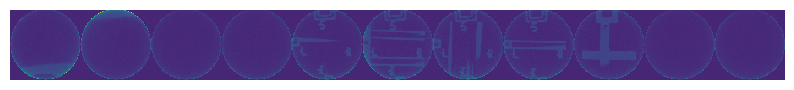

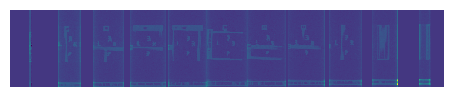

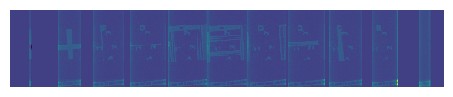

In [5]:
tools.plot_slices(A1, "axial", 100, decimate=4); 
tools.plot_slices(A1, "coronal", 50, decimate=10); 
tools.plot_slices(A1, "sagittal", 50, decimate=10); 

In [6]:
aff1

array([[  0.076     ,   0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,   0.0759964 ,  67.81500244],
       [  0.        ,   0.076     ,   0.        , -38.83599854],
       [  0.        ,   0.        ,   0.        ,   1.        ]])

In [7]:
(A2, aff2) = tools.compute_subresolution_A1_aligned(
    # A1, (0.391, 0.391, 0.391), (2.5, 2.5, 2.5), nrand=1000)
    A1, (0.076, 0.076, 0.076), (1.25, 1.25, 1.25), nrand=1000)

In [8]:
A2.shape

(32, 32, 62)

In [9]:
(A0, aff0) = tools.load_template("../templates/template-phantom-ct_resolution-1250.nii.gz")

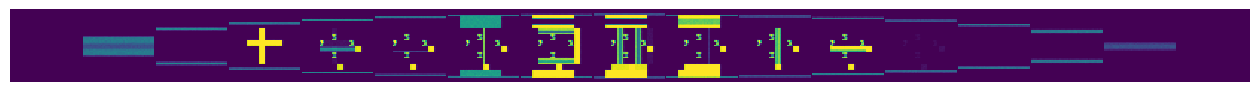

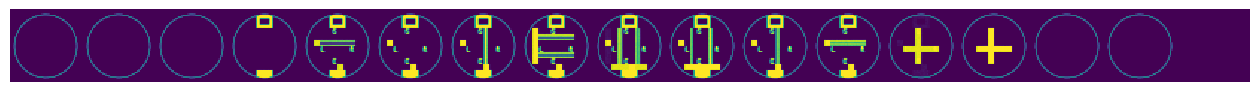

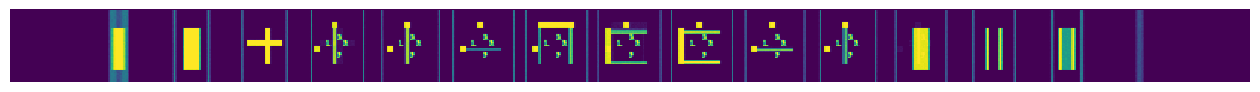

In [10]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A0, mode, 3); 

In [11]:
A0r = A0[10:-10, 10:-10, 10:-10]
print(A0r.shape)
patterns = tools.compute_patterns(A0r)

(29, 29, 29)


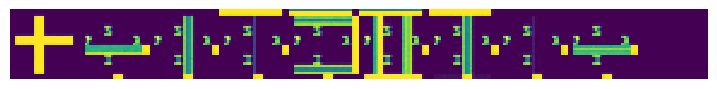

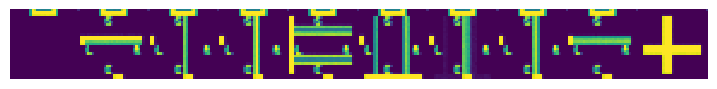

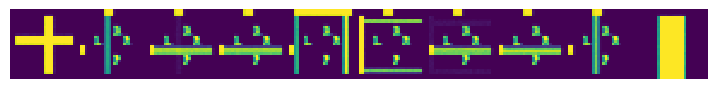

In [12]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A0r, mode, 3); 

In [13]:
A2.shape

(32, 32, 62)

In [14]:
A2r = A2[:, :, :] #A2[:, :, 17:-13]

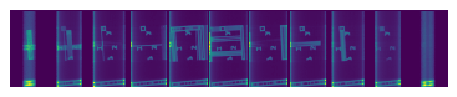

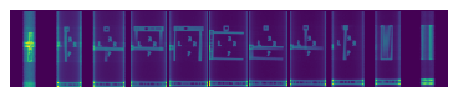

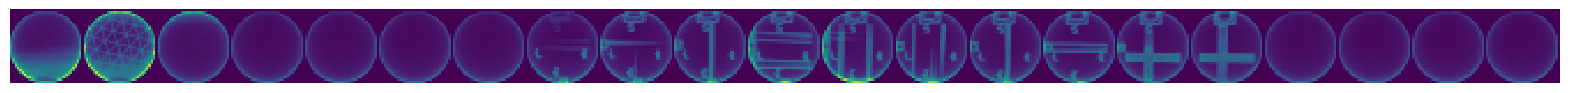

In [15]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A2r, mode, 3); 

In [16]:
print(A0r.shape, A2r.shape, tools.ext.np.min(A2r), tools.ext.np.max(A2r))

(29, 29, 29) (32, 32, 62) -0.838 4533.042


In [17]:
import time

In [18]:
res = {}
t1 = time.time()
for k in patterns: 
    Ak = patterns[k]
    ck = tools.compute_A_inside_B_best_translation(Ak, A2)
    res[k] = {"i": ck[0], "j": ck[1], "k": ck[2], "c": ck[3]}
t2 = time.time()
print(t2 - t1)
df1 = tools.ext.pd.DataFrame(res)
df2 = df1.T
df3 = df2.sort_values(by="c")

23.202680587768555


In [19]:
df3

,i,j,k,c
"True_False_False_(1, 0, 2)",3.0,0.0,19.0,0.331380
"True_False_True_(1, 0, 2)",0.0,2.0,31.0,0.337494
"True_False_True_(0, 1, 2)",2.0,2.0,33.0,0.354819
"True_True_True_(0, 1, 2)",2.0,0.0,20.0,0.364088
"True_False_False_(0, 1, 2)",2.0,2.0,21.0,0.374473
"True_True_False_(2, 0, 1)",3.0,2.0,31.0,0.376890
"False_False_False_(1, 0, 2)",3.0,0.0,18.0,0.378172
"False_False_False_(2, 1, 0)",0.0,2.0,25.0,0.378497
"False_False_True_(0, 1, 2)",1.0,2.0,21.0,0.379106
"True_True_True_(1, 0, 2)",0.0,0.0,18.0,0.380341


In [20]:
aff1

array([[  0.076     ,   0.        ,   0.        ,   0.        ],
       [  0.        ,   0.        ,   0.0759964 ,  67.81500244],
       [  0.        ,   0.076     ,   0.        , -38.83599854],
       [  0.        ,   0.        ,   0.        ,   1.        ]])

In [21]:
(flips1, orientations1) = tools.compute_flips_permutations(aff1)

In [22]:
(flips2, orientations2) = ([False, False, False], [0, 2, 1])

In [23]:
tools.test_flips_orientations(flips1, flips2, orientations1, orientations2)

'......'